# Exercice 2 — Analyse de la production



## Question 1

**Objectif :** calculer les énergies produites annuellement par chaque filière de production étudiée, puis leurs proportions relatives dans le mix de production.

Filières demandées : éolien terrestre, photovoltaïque, hydraulique au fil de l’eau, gaz, fioul et nucléaire.

> Remarque : les puissances du fichier sont horaires et en MW. Comme le pas de temps est de 1 h, la somme des puissances horaires donne directement une énergie en MWh.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the hourly electricity data for France in 2024
# The file uses ";" as separator
df = pd.read_csv(
    "edunao-files/Donnees_France_2024_fr_cet.csv",
    sep=";",
    parse_dates=["Index"]
)

# Use the timestamp column as the DataFrame index
df = df.set_index("Index")

# Convert all data columns to numeric values
# Missing or invalid values are converted to NaN
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Display the first rows to check that the data was imported correctly
df.head()

,Load,Biomass,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage Generation,Hydro Pumped Storage Consumption,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Solar,Waste,Wind Offshore,Wind Onshore
Index,,,,,,,,,,,,,,
2024-01-01 00:00:00+01:00,52847,343,1810,15.0,162,NaN,2033.0,4822,1481,40387,225,87,578.0,14399
2024-01-01 01:00:00+01:00,51600,343,1840,16.0,191,NaN,2067.0,4767,1282,37528,0,83,577.0,14157
2024-01-01 02:00:00+01:00,50992,343,1787,16.0,190,NaN,1685.0,4918,1005,37320,0,87,578.0,13789
2024-01-01 03:00:00+01:00,48187,343,1778,15.0,190,NaN,1989.0,4876,936,36954,0,87,577.0,12816
2024-01-01 04:00:00+01:00,46479,343,1765,15.0,191,NaN,1967.0,4863,798,36906,0,88,576.0,8031


Cell 2 — Define the production sources studied in Exercise 2

In [3]:
# Production sources required in Exercise 2
# We map the original CSV column names to clearer English labels

sources = {
    "Wind Onshore": "Onshore wind",
    "Solar": "Solar PV",
    "Hydro Run-of-river and poundage": "Run-of-river hydro",
    "Fossil Gas": "Gas",
    "Fossil Oil": "Oil",
    "Nuclear": "Nuclear"
}

# Select only the columns used in this question
production = df[list(sources.keys())].rename(columns=sources)

production.head()

,Onshore wind,Solar PV,Run-of-river hydro,Gas,Oil,Nuclear
Index,,,,,,
2024-01-01 00:00:00+01:00,14399,225,4822,1810,162,40387
2024-01-01 01:00:00+01:00,14157,0,4767,1840,191,37528
2024-01-01 02:00:00+01:00,13789,0,4918,1787,190,37320
2024-01-01 03:00:00+01:00,12816,0,4876,1778,190,36954
2024-01-01 04:00:00+01:00,8031,0,4863,1765,191,36906


Cell 3 — Compute annual energy produced by each source

In [4]:
# The data is hourly power in MW.
# Since each value represents one hour, summing MW over all hours gives energy in MWh.

annual_energy_mwh = production.sum()

# Convert MWh to TWh
annual_energy_twh = annual_energy_mwh / 1_000_000

annual_energy_twh

Onshore wind           41.914779
Solar PV               23.322092
Run-of-river hydro     45.894226
Gas                    17.227893
Oil                     1.393593
Nuclear               360.097767
dtype: float64

Cell 3 — Compute annual energy produced by each source

In [5]:
# The data is hourly power in MW.
# Since each value represents one hour, summing MW over all hours gives energy in MWh.

annual_energy_mwh = production.sum()

# Convert MWh to TWh
annual_energy_twh = annual_energy_mwh / 1_000_000

annual_energy_twh

Onshore wind           41.914779
Solar PV               23.322092
Run-of-river hydro     45.894226
Gas                    17.227893
Oil                     1.393593
Nuclear               360.097767
dtype: float64

Cell 4 — Compute relative shares in the studied production mix

In [6]:
# Total annual production from the six studied sources
total_studied_mix_twh = annual_energy_twh.sum()

# Relative share of each source among the six studied sources
share_studied_mix = annual_energy_twh / total_studied_mix_twh * 100

share_studied_mix

Onshore wind           8.556650
Solar PV               4.761065
Run-of-river hydro     9.369030
Gas                    3.516971
Oil                    0.284494
Nuclear               73.511791
dtype: float64

Cell 5 — Create a clean results table

In [8]:
# Build a summary table with annual energy and percentage share

results = pd.DataFrame({
    "Annual energy produced (TWh)": annual_energy_twh,
    "Share among studied sources (%)": share_studied_mix
})

# Round values for readability
results = results.round(2)

results

,Annual energy produced (TWh),Share among studied sources (%)
Onshore wind,41.91,8.56
Solar PV,23.32,4.76
Run-of-river hydro,45.89,9.37
Gas,17.23,3.52
Oil,1.39,0.28
Nuclear,360.10,73.51


Cell 6 — Optional: compute share in the total recorded production mix

In [9]:
# Optional calculation:
# This includes all production sources available in the CSV, not only the six requested sources.

generation_columns = [
    "Biomass",
    "Fossil Gas",
    "Fossil Hard coal",
    "Fossil Oil",
    "Hydro Pumped Storage Generation",
    "Hydro Run-of-river and poundage",
    "Hydro Water Reservoir",
    "Nuclear",
    "Solar",
    "Waste",
    "Wind Offshore",
    "Wind Onshore"
]

# Keep only columns that actually exist in the file
generation_columns = [col for col in generation_columns if col in df.columns]

# Compute total annual recorded production
total_recorded_generation_twh = df[generation_columns].sum().sum() / 1_000_000

# Add this second share to the table
results["Share in total recorded production (%)"] = (
    annual_energy_twh / total_recorded_generation_twh * 100
).round(2)

results

,Annual energy produced (TWh),Share among studied sources (%),Share in total recorded production (%)
Onshore wind,41.91,8.56,8.00
Solar PV,23.32,4.76,4.45
Run-of-river hydro,45.89,9.37,8.76
Gas,17.23,3.52,3.29
Oil,1.39,0.28,0.27
Nuclear,360.10,73.51,68.76


## Question 2

Calculate the capacity factors of each production source.

The capacity factor is defined as:

\[
fc = \frac{\text{Annual energy produced}}{\text{Installed capacity} \times \text{Number of hours in the year}}
\]

We use the installed capacities from `Capacites_France_2024.csv`.

Load the installed capacity file

In [11]:
# Load the installed capacity file
# This file uses ";" as separator and decimal commas, such as "1403,0"

capacities = pd.read_csv(
    "edunao-files/Capacites_France_2024.csv",
    sep=";"
)

# Rename the first unnamed column to make it clearer
capacities = capacities.rename(columns={"Unnamed: 0": "Index"})

capacities.head()

,Index,Biomass,Fossil Gas,Fossil Hard coal,Fossil Oil,Geothermal,Hydro Pumped Storage,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Solar,Waste,Wind Offshore,Wind Onshore
0,2024-01-01 00:00:00+01:00,"1403,0","13133,0","1812,0","3042,0","2,0","5065,0","11598,0","8787,0","243,0","61370,0","1032,0","17419,0","968,0","1483,0","22134,0"


Cell 3 — Convert capacity values to numeric values

In [13]:
# Convert all capacity columns from strings with decimal commas to numeric values

for col in capacities.columns:
    if col != "Index":
        capacities[col] = (
            capacities[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
        )
        capacities[col] = pd.to_numeric(capacities[col], errors="coerce")

capacities.head()

,Index,Biomass,Fossil Gas,Fossil Hard coal,Fossil Oil,Geothermal,Hydro Pumped Storage,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Solar,Waste,Wind Offshore,Wind Onshore
0,2024-01-01 00:00:00+01:00,1403.0,13133.0,1812.0,3042.0,2.0,5065.0,11598.0,8787.0,243.0,61370.0,1032.0,17419.0,968.0,1483.0,22134.0


Cell 4 — Extract installed capacity for the studied sources

In [14]:
# Select the installed capacity of the six production sources studied in Exercise 2

installed_capacity_mw = capacities.loc[0, list(sources.keys())]

# Rename the index using the clearer labels defined in Question 1
installed_capacity_mw = installed_capacity_mw.rename(index=sources)

installed_capacity_mw

Onshore wind          22134.0
Solar PV              17419.0
Run-of-river hydro    11598.0
Gas                   13133.0
Oil                    3042.0
Nuclear               61370.0
Name: 0, dtype: float64

Cell 5 — Compute the number of hours in the year

In [15]:
# The production data is hourly.
# Therefore, the number of hours in the year is the number of rows in the production DataFrame.
# For 2024, this should be 8784 because 2024 is a leap year.

number_of_hours = len(production)

print("Number of hourly values:", number_of_hours)

Number of hourly values: 8784


Cell 6 — Compute the capacity factors

In [17]:
# Capacity factor formula:
# capacity factor = annual energy produced / (installed capacity * number of hours)
#
# annual_energy_mwh was already computed in Question 1.
# installed_capacity_mw is in MW.
# number_of_hours is in hours.
#
# Therefore, installed_capacity_mw * number_of_hours gives the maximum possible annual energy in MWh.

capacity_factor = annual_energy_mwh / (installed_capacity_mw * number_of_hours)

capacity_factor_percent = capacity_factor * 100

capacity_factor_percent

Onshore wind          21.558322
Solar PV              15.242351
Run-of-river hydro    45.048737
Gas                   14.933991
Oil                    5.215362
Nuclear               66.799310
dtype: float64

Cell 7 — Create a clean results table

In [18]:
# Build a summary table with annual energy, installed capacity, and capacity factor

capacity_factor_results = pd.DataFrame({
    "Annual energy produced (TWh)": annual_energy_mwh / 1_000_000,
    "Installed capacity (MW)": installed_capacity_mw,
    "Capacity factor (%)": capacity_factor_percent
})

capacity_factor_results = capacity_factor_results.round(2)

capacity_factor_results

,Annual energy produced (TWh),Installed capacity (MW),Capacity factor (%)
Onshore wind,41.91,22134.0,21.56
Solar PV,23.32,17419.0,15.24
Run-of-river hydro,45.89,11598.0,45.05
Gas,17.23,13133.0,14.93
Oil,1.39,3042.0,5.22
Nuclear,360.10,61370.0,66.80


Cell 8 — Plot the capacity factors

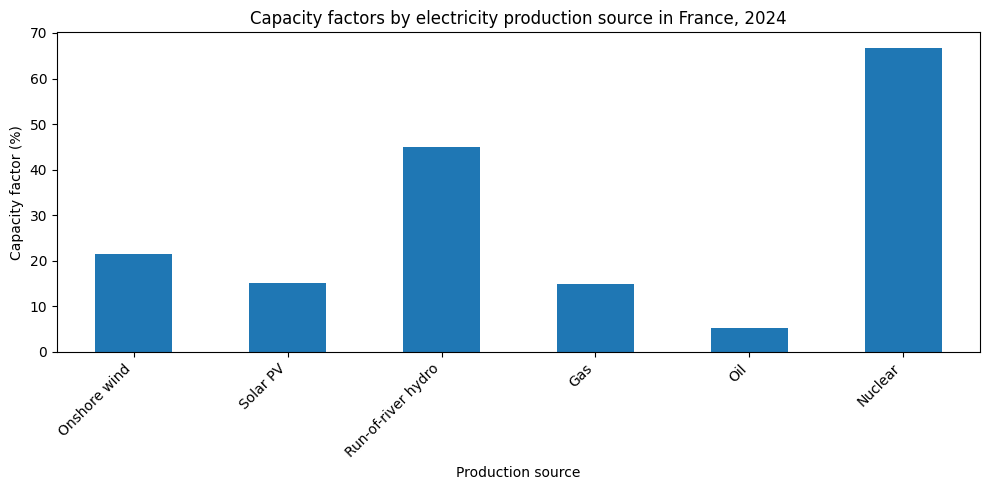

In [19]:
# Bar plot of capacity factors by production source

ax = capacity_factor_percent.plot(kind="bar", figsize=(10, 5))

ax.set_title("Capacity factors by electricity production source in France, 2024")
ax.set_xlabel("Production source")
ax.set_ylabel("Capacity factor (%)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Cell 9 — Short written conclusion

In [20]:
# Print a short automatic interpretation

print("Conclusion:")
print("The capacity factor measures how much a production source actually produced")
print("compared with the maximum energy it could have produced if it had operated")
print("at full installed capacity during the whole year.")
print()

print("Nuclear has a high capacity factor because it is designed to operate many hours per year.")
print("Run-of-river hydro also has a relatively high capacity factor because water flow is often available.")
print("Solar PV has a lower capacity factor because production only occurs during daylight and depends on weather.")
print("Onshore wind depends on wind conditions, so its capacity factor is moderate.")
print("Gas and oil have low capacity factors because they are mainly used as flexible or backup production sources.")

Conclusion:
The capacity factor measures how much a production source actually produced
compared with the maximum energy it could have produced if it had operated
at full installed capacity during the whole year.

Nuclear has a high capacity factor because it is designed to operate many hours per year.
Run-of-river hydro also has a relatively high capacity factor because water flow is often available.
Solar PV has a lower capacity factor because production only occurs during daylight and depends on weather.
Onshore wind depends on wind conditions, so its capacity factor is moderate.
Gas and oil have low capacity factors because they are mainly used as flexible or backup production sources.


## Question 3

The net consumption is defined as:

\[
\text{Net consumption} = \text{Gross consumption} - \text{Fatal production}
\]

In this question, the fatal production sources are:

- Onshore wind
- Solar PV
- Run-of-river hydro

We will compute the net consumption and plot it as a function of time.

Cell 2 — Define fatal production sources

In [21]:
# Define the fatal production sources required in Question 3
# These are the sources that are considered non-dispatchable in this simplified model.

fatal_sources = [
    "Wind Onshore",
    "Solar",
    "Hydro Run-of-river and poundage"
]

# Check that all required columns exist in the DataFrame
for col in fatal_sources:
    if col not in df.columns:
        print(f"Warning: column not found: {col}")

# Display the first rows of the fatal production data
df[fatal_sources].head()

,Wind Onshore,Solar,Hydro Run-of-river and poundage
Index,,,
2024-01-01 00:00:00+01:00,14399,225,4822
2024-01-01 01:00:00+01:00,14157,0,4767
2024-01-01 02:00:00+01:00,13789,0,4918
2024-01-01 03:00:00+01:00,12816,0,4876
2024-01-01 04:00:00+01:00,8031,0,4863


Cell 3 — Compute fatal production

In [22]:
# Compute total fatal production at each hour.
# The data is given in MW, so the sum is also in MW.

fatal_production_mw = df[fatal_sources].fillna(0).sum(axis=1)

fatal_production_mw.head()

Index
2024-01-01 00:00:00+01:00    19446
2024-01-01 01:00:00+01:00    18924
2024-01-01 02:00:00+01:00    18707
2024-01-01 03:00:00+01:00    17692
2024-01-01 04:00:00+01:00    12894
dtype: int64

Cell 4 — Compute gross and net consumption

In [23]:
# Gross consumption is given by the "Load" column.
# It represents the total electricity demand before subtracting fatal production.

gross_consumption_mw = df["Load"]

# Net consumption is the demand that remains after subtracting fatal production.
# This remaining demand must be supplied by dispatchable sources such as nuclear, gas, oil, etc.

net_consumption_mw = gross_consumption_mw - fatal_production_mw

net_consumption_mw.head()

Index
2024-01-01 00:00:00+01:00    33401
2024-01-01 01:00:00+01:00    32676
2024-01-01 02:00:00+01:00    32285
2024-01-01 03:00:00+01:00    30495
2024-01-01 04:00:00+01:00    33585
dtype: int64

Cell 5 — Create a clean summary table

In [24]:
# Build a DataFrame to make the results easier to inspect

net_consumption_df = pd.DataFrame({
    "Gross consumption (MW)": gross_consumption_mw,
    "Fatal production (MW)": fatal_production_mw,
    "Net consumption (MW)": net_consumption_mw
})

net_consumption_df.head()

,Gross consumption (MW),Fatal production (MW),Net consumption (MW)
Index,,,
2024-01-01 00:00:00+01:00,52847,19446,33401
2024-01-01 01:00:00+01:00,51600,18924,32676
2024-01-01 02:00:00+01:00,50992,18707,32285
2024-01-01 03:00:00+01:00,48187,17692,30495
2024-01-01 04:00:00+01:00,46479,12894,33585


Cell 6 — Plot net consumption over time

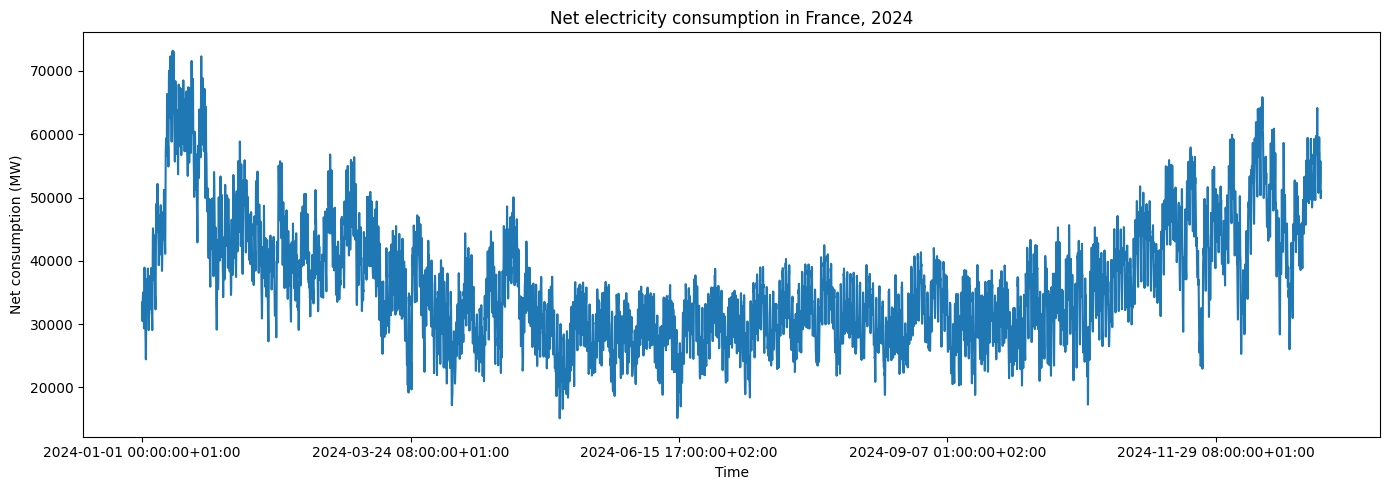

In [25]:
# Plot the net consumption as a function of time

ax = net_consumption_mw.plot(figsize=(14, 5))

ax.set_title("Net electricity consumption in France, 2024")
ax.set_xlabel("Time")
ax.set_ylabel("Net consumption (MW)")

plt.tight_layout()
plt.show()

Cell 7 — Plot gross consumption and net consumption together

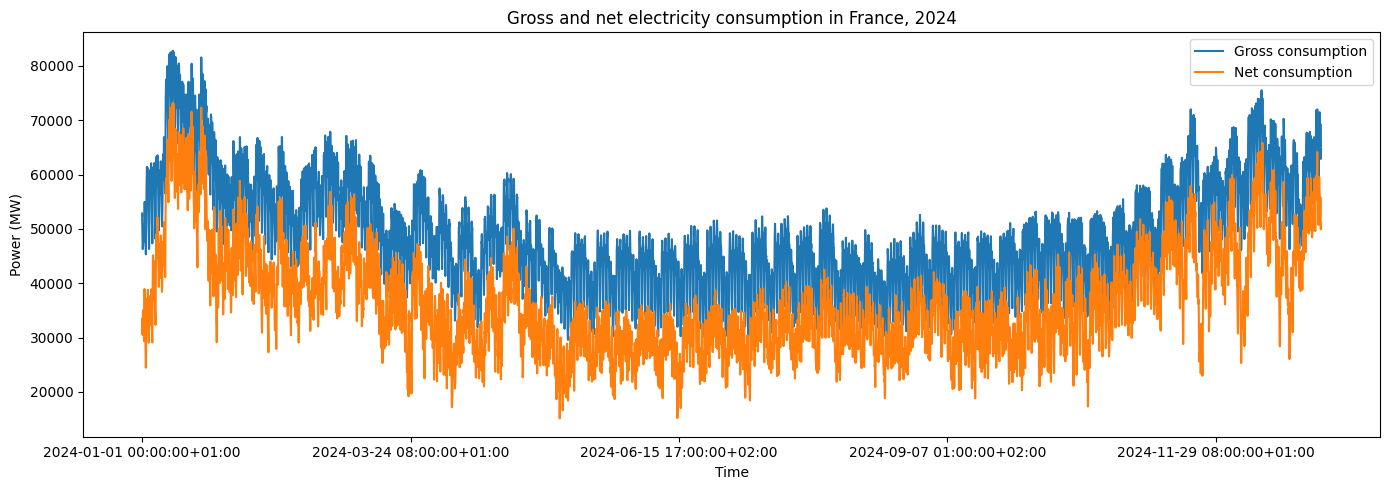

In [26]:
# Plot gross consumption and net consumption on the same graph for comparison

ax = gross_consumption_mw.plot(figsize=(14, 5), label="Gross consumption")
net_consumption_mw.plot(ax=ax, label="Net consumption")

ax.set_title("Gross and net electricity consumption in France, 2024")
ax.set_xlabel("Time")
ax.set_ylabel("Power (MW)")

ax.legend()
plt.tight_layout()
plt.show()

Cell 8 — Basic statistics

In [27]:
# Compute basic statistics to quantify the effect of fatal production

average_gross_consumption = gross_consumption_mw.mean()
average_net_consumption = net_consumption_mw.mean()
average_fatal_production = fatal_production_mw.mean()

max_net_consumption = net_consumption_mw.max()
min_net_consumption = net_consumption_mw.min()

print("Average gross consumption:", round(average_gross_consumption, 2), "MW")
print("Average fatal production:", round(average_fatal_production, 2), "MW")
print("Average net consumption:", round(average_net_consumption, 2), "MW")
print()
print("Maximum net consumption:", round(max_net_consumption, 2), "MW")
print("Minimum net consumption:", round(min_net_consumption, 2), "MW")

Average gross consumption: 48916.87 MW
Average fatal production: 12651.54 MW
Average net consumption: 36265.33 MW

Maximum net consumption: 73199 MW
Minimum net consumption: 15127 MW


Cell 9 — Short written conclusion

In [28]:
# Print a short interpretation

print("Conclusion:")
print("The net consumption is lower than the gross consumption because part of the demand")
print("is already supplied by fatal renewable production: onshore wind, solar PV, and run-of-river hydro.")
print()
print("The difference between gross and net consumption changes over time because wind and solar production")
print("are variable. Solar production follows a daily cycle, while wind production depends on weather conditions.")
print()
print("This net consumption curve represents the remaining demand that must be supplied by dispatchable")
print("production sources or storage.")

Conclusion:
The net consumption is lower than the gross consumption because part of the demand
is already supplied by fatal renewable production: onshore wind, solar PV, and run-of-river hydro.

The difference between gross and net consumption changes over time because wind and solar production
are variable. Solar production follows a daily cycle, while wind production depends on weather conditions.

This net consumption curve represents the remaining demand that must be supplied by dispatchable
production sources or storage.


## Question 4

We now plot the load duration curve of the net consumption and compare it with the gross consumption.

A load duration curve is obtained by sorting the hourly power values in decreasing order.

It does not show the chronological evolution anymore.  
Instead, it shows how many hours per year the consumption is above a given power level.

In [29]:
# Sort gross consumption and net consumption in decreasing order.
# This gives the load duration curves.

gross_consumption_sorted = gross_consumption_mw.sort_values(ascending=False).reset_index(drop=True)
net_consumption_sorted = net_consumption_mw.sort_values(ascending=False).reset_index(drop=True)

# Create an hour index from 1 to the number of hours in the year
hours = range(1, len(gross_consumption_sorted) + 1)

gross_consumption_sorted.head(), net_consumption_sorted.head()

(0    82800
 1    82582
 2    82505
 3    82482
 4    82436
 Name: Load, dtype: int64,
 0    73199
 1    73060
 2    72880
 3    72648
 4    72631
 dtype: int64)

Cell 3 — Plot both load duration curves

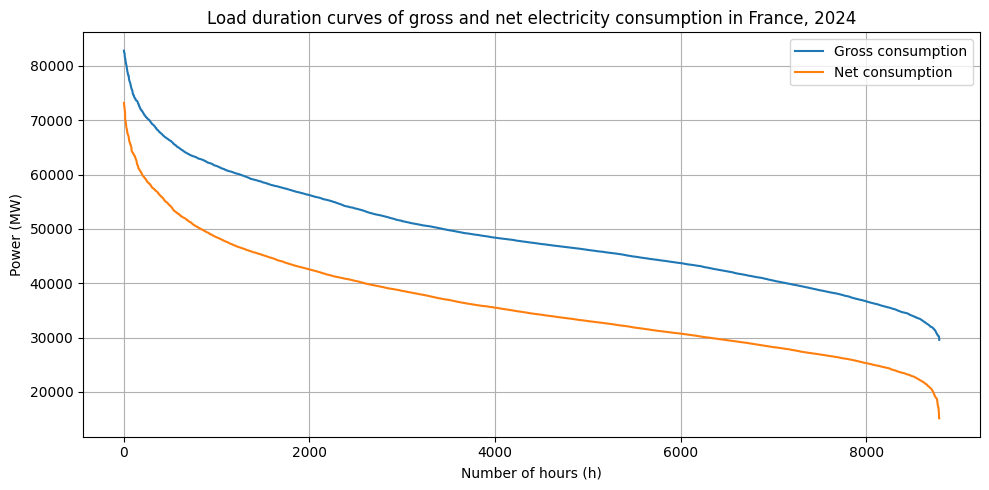

In [31]:
# Plot the gross and net load duration curves on the same graph

plt.figure(figsize=(10, 5))

plt.plot(hours, gross_consumption_sorted, label="Gross consumption")
plt.plot(hours, net_consumption_sorted, label="Net consumption")

plt.title("Load duration curves of gross and net electricity consumption in France, 2024")
plt.xlabel("Number of hours (h)")
plt.ylabel("Power (MW)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Cell 4 — Plot in GW for better readability

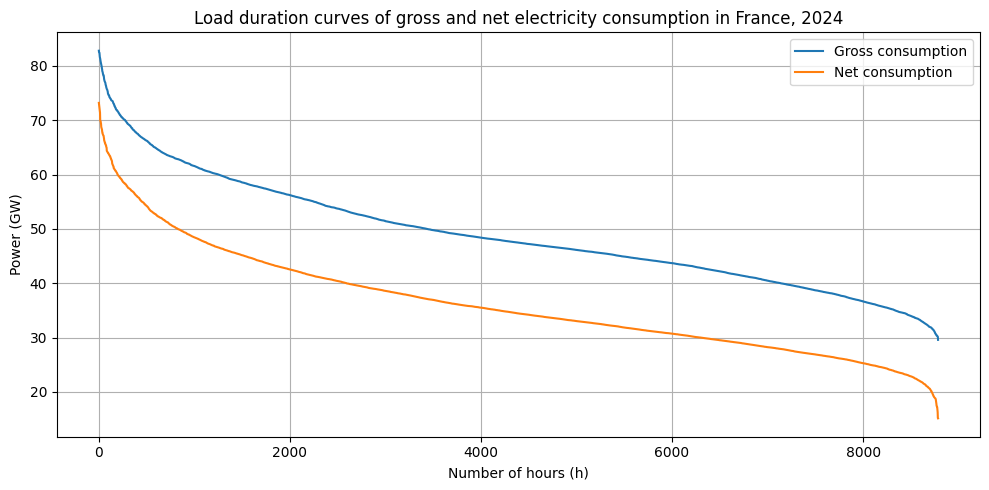

In [33]:
# Same plot, but using GW instead of MW for better readability

plt.figure(figsize=(10, 5))

plt.plot(hours, gross_consumption_sorted / 1000, label="Gross consumption")
plt.plot(hours, net_consumption_sorted / 1000, label="Net consumption")

plt.title("Load duration curves of gross and net electricity consumption in France, 2024")
plt.xlabel("Number of hours (h)")
plt.ylabel("Power (GW)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Cell 5 — Compute useful indicators

In [34]:
# Compute a few useful values to interpret the curves

summary_q4 = pd.DataFrame({
    "Gross consumption (MW)": [
        gross_consumption_mw.max(),
        gross_consumption_mw.mean(),
        gross_consumption_mw.min()
    ],
    "Net consumption (MW)": [
        net_consumption_mw.max(),
        net_consumption_mw.mean(),
        net_consumption_mw.min()
    ]
}, index=["Maximum", "Average", "Minimum"])

summary_q4 = summary_q4.round(2)

summary_q4

,Gross consumption (MW),Net consumption (MW)
Maximum,82800.00,73199.00
Average,48916.87,36265.33
Minimum,29575.00,15127.00


Cell 6 — Compute the average reduction caused by fatal production

In [35]:
# The vertical difference between the two curves represents the contribution of fatal production.
# Here we compute the average reduction from gross to net consumption.

average_reduction_mw = gross_consumption_mw.mean() - net_consumption_mw.mean()
average_reduction_percent = average_reduction_mw / gross_consumption_mw.mean() * 100

print("Average reduction due to fatal production:")
print(f"{average_reduction_mw:.2f} MW")
print(f"{average_reduction_percent:.2f} % of average gross consumption")

Average reduction due to fatal production:
12651.54 MW
25.86 % of average gross consumption


Cell 7 — Short written conclusion

In [36]:
# Print a short interpretation

print("Conclusion:")
print("The load duration curve of net consumption is below the gross consumption curve.")
print("This is because fatal renewable production reduces the amount of demand that must be supplied")
print("by dispatchable power plants.")
print()
print("The reduction is not constant over the year because wind and solar production are variable.")
print("The net consumption curve is therefore useful for sizing the dispatchable production fleet,")
print("because it represents the residual demand after fatal renewable generation.")

Conclusion:
The load duration curve of net consumption is below the gross consumption curve.
This is because fatal renewable production reduces the amount of demand that must be supplied
by dispatchable power plants.

The reduction is not constant over the year because wind and solar production are variable.
The net consumption curve is therefore useful for sizing the dispatchable production fleet,
because it represents the residual demand after fatal renewable generation.
